<a href="https://colab.research.google.com/github/dwelle511/2026BDA/blob/main/BDA_Day01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 간단한 데이터 시각화 실습
[markdown definition](https://www.markdownguide.org/cheat-sheet)


In [ ]:
#
print("e");

e


In [ ]:
#
import sys
sys.version

'3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]'

In [ ]:
import site
site.getsitepackages() # 클라우드로 코딩하는거라 미국에있는 본사 경로이다

['/usr/local/lib/python3.12/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/lib/python3.12/dist-packages']

In [ ]:
#version check
import numpy as np
import matplotlib as mpl

np.__version__
#mpl.__version__

'2.0.2'

In [ ]:
#to make picture clear
%config InlineBackend.figure_format= 'retina' #외우기
#to usable korean, moduel
!pip install koreanize-matplotlib

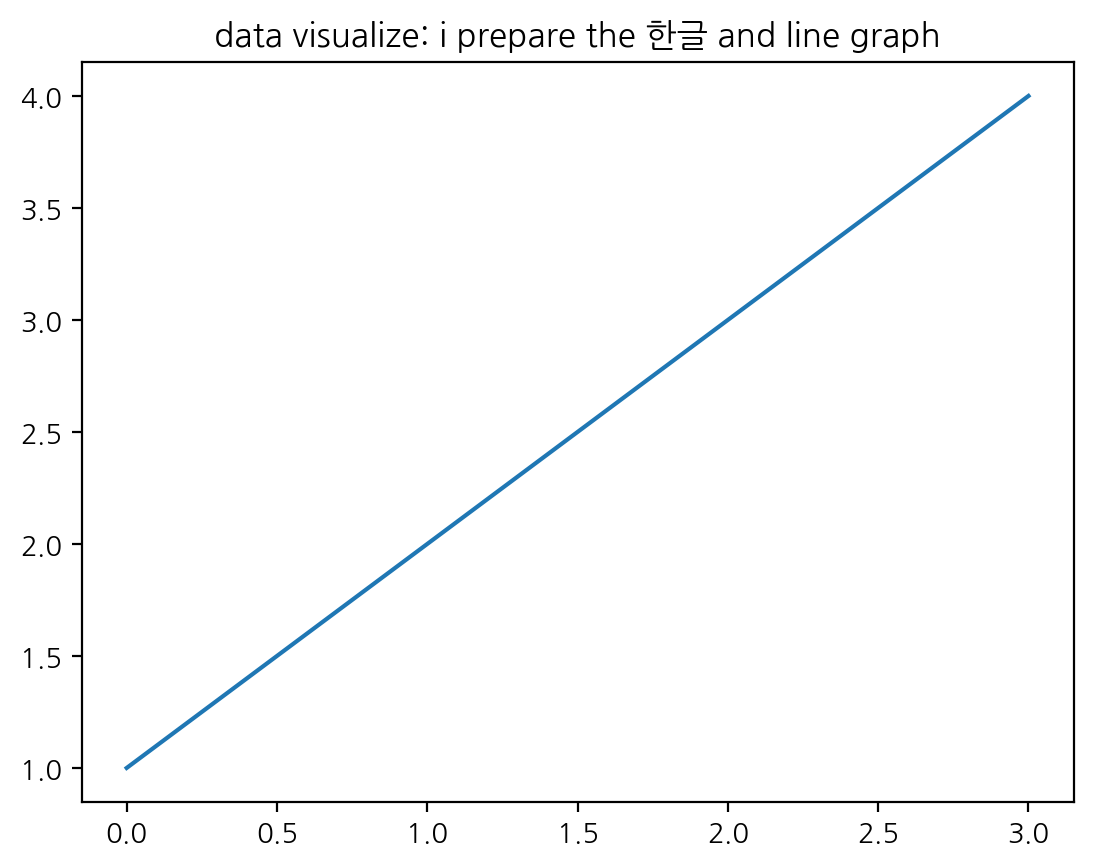

In [ ]:
#3.download the import (is essential package)
import koreanize_matplotlib
import matplotlib.pyplot as plt

#직선 그리기
import matplotlib.pyplot as plt
plt.title("data visualize: i prepare the 한글 and line graph")
plt.plot([1,2,3,4])
plt.show()

In [ ]:
#첫 열은 index, 콤마가 들어가 값은 정수로 파일을 읽어 pop에 저장
import pandas as ppp # 자료 이름 popmonth로
pop= ppp.read_csv("/content/popmonth.csv",encoding='cp949',index_col=0,thousands=',')
pop

,2026년02월_총인구수,2026년02월_세대수,2026년02월_세대당 인구,2026년02월_남자 인구수,2026년02월_여자 인구수,2026년02월_남여 비율
행정구역,,,,,,
전국 (1000000000),51106229,24350797,2.10,25429357,25676872,0.99
서울특별시 (1100000000),9304129,4512818,2.06,4482300,4821829,0.93
부산광역시 (2600000000),3239016,1576653,2.05,1574040,1664976,0.95
대구광역시 (2700000000),2351461,1115161,2.11,1151654,1199807,0.96
인천광역시 (2800000000),3054367,1404284,2.18,1525266,1529101,1.00
광주광역시 (2900000000),1389235,659087,2.11,685321,703914,0.97
대전광역시 (3000000000),1441405,699675,2.06,718084,723321,0.99
울산광역시 (3100000000),1089835,499950,2.18,561965,527870,1.06
세종특별자치시 (3600000000),391240,165449,2.36,194784,196456,0.99


In [ ]:
#첫 5col 표시
pop.columns= ['총인구수','세대수','세대당인구','남자인구수','여자인구수','남여비율']
pop.head()

,총인구수,세대수,세대당인구,남자인구수,여자인구수,남여비율
행정구역,,,,,,
전국 (1000000000),51106229,24350797,2.10,25429357,25676872,0.99
서울특별시 (1100000000),9304129,4512818,2.06,4482300,4821829,0.93
부산광역시 (2600000000),3239016,1576653,2.05,1574040,1664976,0.95
대구광역시 (2700000000),2351461,1115161,2.11,1151654,1199807,0.96
인천광역시 (2800000000),3054367,1404284,2.18,1525266,1529101,1.00


In [ ]:
#행정구역별 남녀 인구수 비교
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 한글 폰트 설정 (환경에 맞게 수정)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic' # Mac
plt.rcParams['axes.unicode_minus'] = False
import koreanize_matplotlib


# 2. 데이터 불러오기 및 전처리
# 인코딩은 보통 'cp949'나 'utf-8-sig'를 사용합니다.
df = pd.read_csv('/content/popmonth.csv', encoding='cp949',index_col=0,thousands=',')

# '행정구역' 열에서 지역명만 추출 (예: '서울특별시 (1100000000)' -> '서울특별시')
df['행정구역'] = df['행정구역'].str.split('(').str[0].str.strip()

# 숫자 데이터 내 쉼표(,) 제거 후 정수형 변환
# CSV 내 실제 컬럼명이 '202X년XX월_남_인구수' 형태일 수 있으니 확인이 필요합니다.
# 여기서는 '남 인구수', '여 인구수'라는 이름으로 가정합니다.
df['남자인구수'] = df['남자인구수'].replace({',': ''}, regex=True).astype(int)
df['여자인구수'] = df['여자인구수'].replace({',': ''}, regex=True).astype(int)

# 3. 데이터 선택 (전국 단위 등 상위 10개 행정구역 예시)
# 첫 번째 행이 '전국'일 경우 제외하려면 df.iloc[1:11] 등을 사용하세요.
sample_df = df.iloc[1:11]

# 4. 그래프 그리기
label = sample_df['행정구역']
x = np.arange(len(label))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - width/2, sample_df['남자인구수'], width, label='남성', color='#3498db')
rects2 = ax.bar(x + width/2, sample_df['여자인구수'], width, label='여성', color='#e74c3c')

# 그래프 꾸미기
ax.set_title('행정구역별 남녀 인구수 비교', fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(label, rotation=45)
ax.legend()

# 천 단위 콤마 포함하여 라벨링
ax.bar_label(rects1, padding=3, fmt='{:,.0f}')
ax.bar_label(rects2, padding=3, fmt='{:,.0f}')

plt.tight_layout()
plt.show()

KeyError: '행정구역'

In [ ]:
print(df.columns)

Index(['2026년02월_총인구수', '2026년02월_세대수', '2026년02월_세대당 인구', '2026년02월_남자 인구수',
       '2026년02월_여자 인구수', '2026년02월_남여 비율'],
      dtype='object')


### 위에거 오류 // 아래거 오류x

/tmp/ipykernel_4284/79521412.py:53: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4284/79521412.py:53: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4284/79521412.py:53: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4284/79521412.py:53: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4284/79521412.py:53: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4284/79521412.py:53: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4284/79521412.py:53: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/i

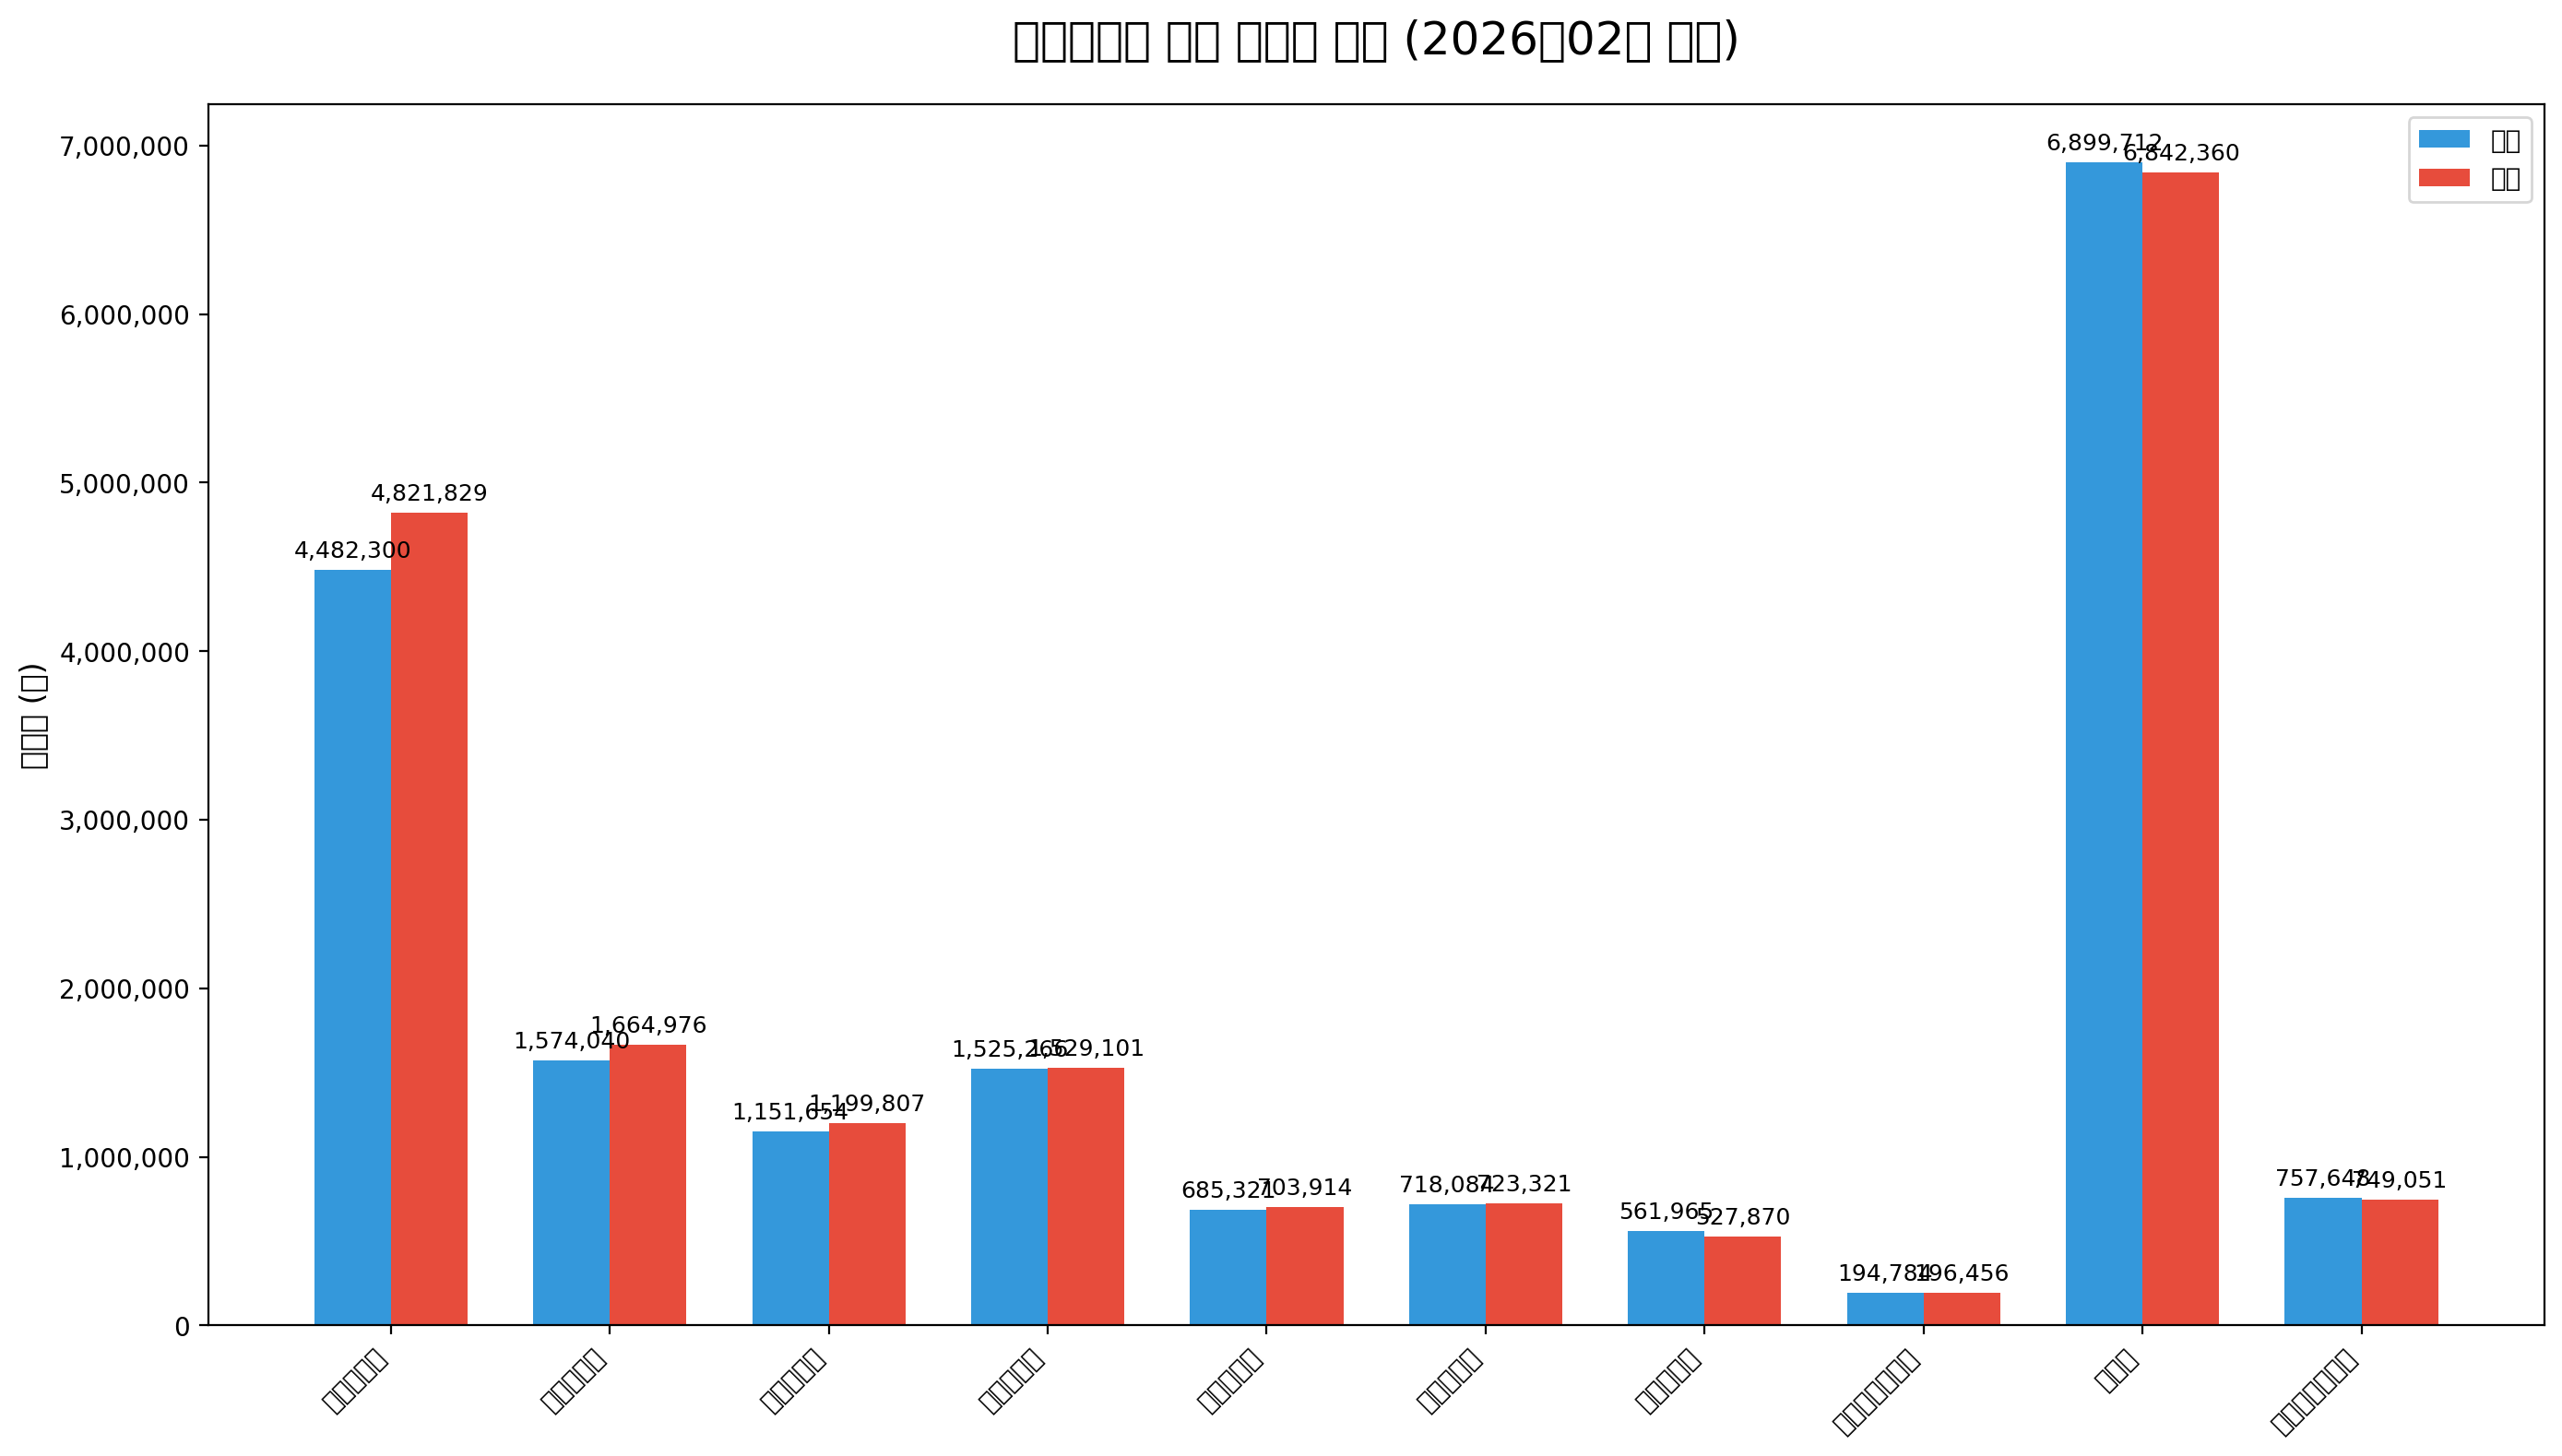

In [ ]:
!pip install koreanize-matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import koreanize_matplotlib

# 1. 데이터 불러오기
# 행정구역 컬럼이 인덱스로 잡히지 않도록 index_col=0은 제거합니다.
df = pd.read_csv('/content/popmonth.csv', encoding='cp949', thousands=',')

# 2. 컬럼명 자동 매칭 (날짜가 붙어있는 컬럼명을 찾습니다)
# '남자 인구수'와 '여자 인구수'라는 글자가 포함된 컬럼을 자동으로 선택
col_male = [c for c in df.columns if '남자 인구수' in c][0]
col_female = [c for c in df.columns if '여자 인구수' in c][0]
col_region = df.columns[0] # 첫 번째 컬럼은 보통 '행정구역'

# 3. 데이터 전처리
# '행정구역' 열에서 코드 번호 제거 및 깔끔하게 정리
df[col_region] = df[col_region].astype(str).str.split('(').str[0].str.strip()

# 숫자형 변환 (thousands=','로 이미 처리되었지만 확실히 하기 위해 astype 사용)
df[col_male] = df[col_male].astype(int)
df[col_female] = df[col_female].astype(int)

# 4. 데이터 선택 (0번 '전국' 제외, 1번부터 10개 지역 추출)
sample_df = df.iloc[1:11]

# 5. 그래프 시각화
label = sample_df[col_region]
x = np.arange(len(label))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))

rects1 = ax.bar(x - width/2, sample_df[col_male], width, label='남성', color='#3498db')
rects2 = ax.bar(x + width/2, sample_df[col_female], width, label='여성', color='#e74c3c')

# 스타일링
ax.set_title(f'행정구역별 남녀 인구수 비교 ({col_male.split("_")[0]} 기준)', fontsize=18, pad=20)
ax.set_ylabel('인구수 (명)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(label, rotation=45, ha='right')
ax.legend()

# Y축 천 단위 콤마
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 막대 위 숫자 표시 (가독성을 위해 폰트 크기 조절)
ax.bar_label(rects1, padding=3, fmt='{:,.0f}', fontsize=9)
ax.bar_label(rects2, padding=3, fmt='{:,.0f}', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
#pop 의 index수정
#도시 이름만으로 구성 # 1행 1열 =행정구역 단어 삭제됨 # sol)코드 번호 없앰
pop.index=[pop.index[i].split()[0] for i in range(len(pop))]
pop

#list 가장 = list comprehension ; 행의 수 만큼 for문 돌리는것
#pop의 행개수 만큼 돌거야 -> 쪼개 -> 앞에거만 남겨= 뒤에 숫자 없애기

,총인구수,세대수,세대당인구,남자인구수,여자인구수,남여비율
전국,51106229,24350797,2.10,25429357,25676872,0.99
서울특별시,9304129,4512818,2.06,4482300,4821829,0.93
부산광역시,3239016,1576653,2.05,1574040,1664976,0.95
대구광역시,2351461,1115161,2.11,1151654,1199807,0.96
인천광역시,3054367,1404284,2.18,1525266,1529101,1.00
광주광역시,1389235,659087,2.11,685321,703914,0.97
대전광역시,1441405,699675,2.06,718084,723321,0.99
울산광역시,1089835,499950,2.18,561965,527870,1.06
세종특별자치시,391240,165449,2.36,194784,196456,0.99
경기도,13742072,6138755,2.24,6899712,6842360,1.01


In [ ]:
pop.index[13] # 행 몇번째거 인지 나옴
   # 그럼 열은 ??

'전북특별자치도'

In [ ]:
pop.index[4].split()[0]

'인천광역시'

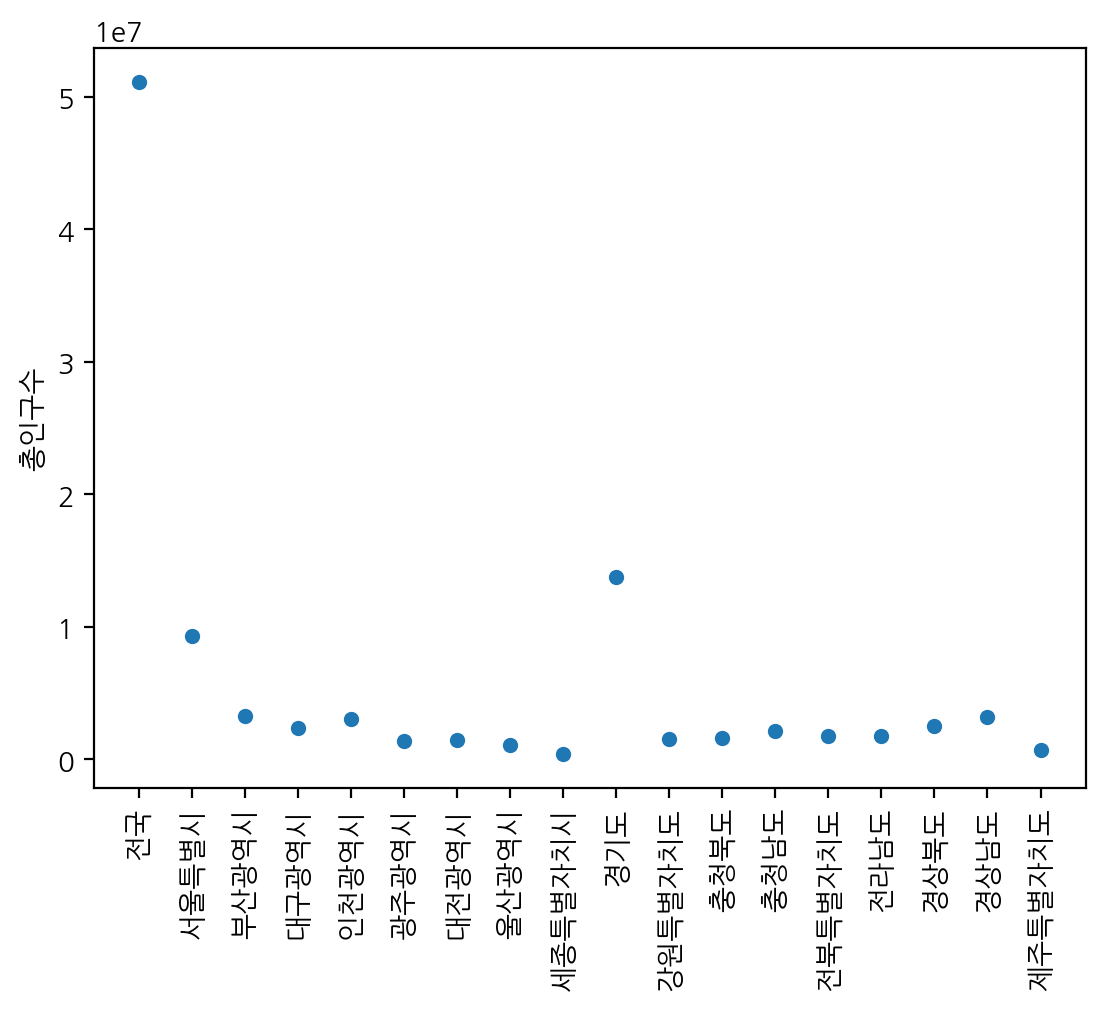

In [ ]:
#seaborndml sns.scatterplot() 을 총인구수 col[0]열
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

sns.scatterplot(pop['총인구수'])
plt.xticks(rotation=90)
plt.show()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

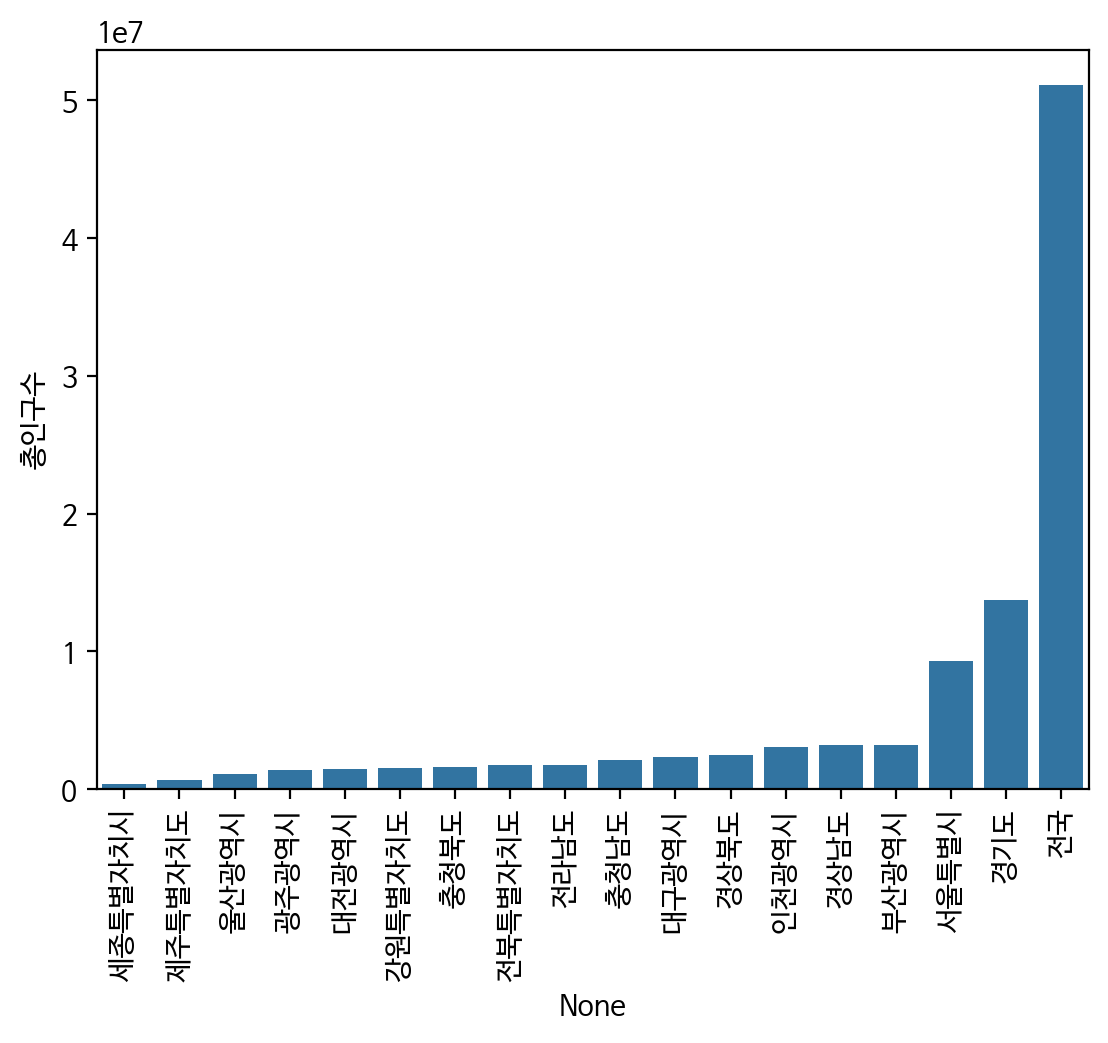

In [ ]:
#총인구수로 정렬해 막대 그래프를 그린 코드
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 1. 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 2. 런타임 다시 시작 후 아래 코드 실행
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

pop1= pop.sort_values('총인구수')
sns.barplot(x=pop1.index, y='총인구수',data=pop1)
plt.xticks(rotation=90)
plt.show()